In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.options.display.float_format = '{:.2f}'.format

In [5]:
#importando o csv
df = pd.read_csv('../data/raw/superstore.csv', sep= ',', encoding='latin1')

In [6]:
#Verificando a quantidade de linhas e colunas
df.shape

(9994, 21)

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
# Pega a parte decimal e mostra os valores únicos
decimais = (df['Postal Code'] % 1).unique()
decimais

# Formata para ter 5 dígitos preenchendo com zero à esquerda
df['Postal Code'] = df['Postal Code'].fillna(5401).astype(int).astype(str).str.zfill(5)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9800 non-null   object 
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors= 'coerce', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors= 'coerce', dayfirst=True)

In [13]:
#Verificando se existem dados de datas inconsistentes 
(df['Ship Date'] < df['Order Date']).sum()


0

In [12]:
test_State = []
duplicated_states = []
stateList = df['State'].unique().tolist()
for i in stateList:
    if i not in test_State:
        test_State.append(i)
    else:
        duplicated_states.append(i)


In [14]:
# Remove espaços no início/fim e padroniza para "Título" (Primeira Letra Maiúscula)
df['State'] = df['State'].str.strip().str.title()



In [15]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,NaT,NaT,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.25,3,0.20,4.10
9990,9991,CA-2017-121258,NaT,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.96,2,0.00,15.63
9991,9992,CA-2017-121258,NaT,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.58,2,0.20,19.39
9992,9993,CA-2017-121258,NaT,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4,0.00,13.32


In [15]:
colunas_texto = ['City', 'State', 'Region', 'Category', 'Product Name', 'Sub-Category']

for col in colunas_texto:
    df[col] = df[col].str.strip().str.title()

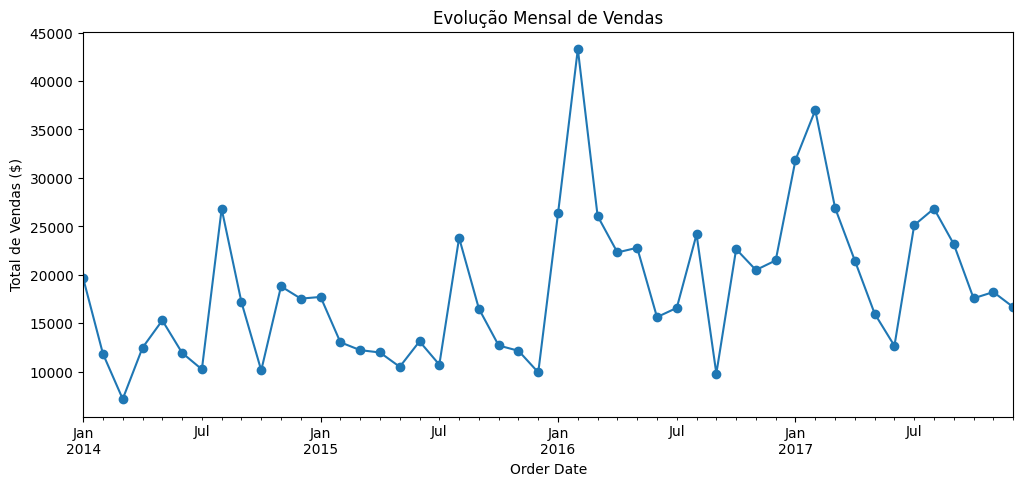

In [16]:

# Agrupar por mês/ano e somar vendas
sales_evolution = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

sales_evolution.plot(figsize=(12, 5), marker='o', title='Evolução Mensal de Vendas')
plt.ylabel('Total de Vendas ($)')
plt.show()

<Axes: title={'center': 'Vendas por Região'}, xlabel='Region'>

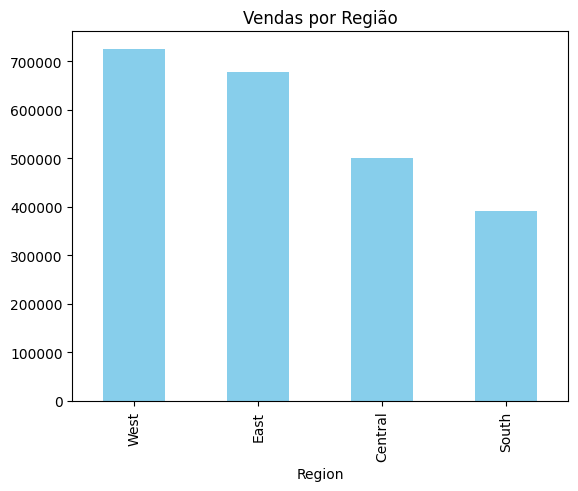

In [17]:
region_performance = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_performance.plot(kind='bar', color='skyblue', title='Vendas por Região')

In [18]:
top_customers = df.groupby(['Customer ID', 'Customer Name'])['Sales'].sum().nlargest(10)
print(top_customers)

Customer ID  Customer Name     
SM-20320     Sean Miller          25043.05
TC-20980     Tamara Chand         19052.22
RB-19360     Raymond Buch         15117.34
TA-21385     Tom Ashbrook         14595.62
AB-10105     Adrian Barton        14473.57
KL-16645     Ken Lonsdale         14175.23
SC-20095     Sanjit Chand         14142.33
HL-15040     Hunter Lopez         12873.30
SE-20110     Sanjit Engle         12209.44
CC-12370     Christopher Conant   12129.07
Name: Sales, dtype: float64


In [19]:
df['Ship_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [20]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Ship_Time
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels For Typewriters B...,14.62,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford Cr4500 Series Slim Rectangular Table,957.58,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal Holdit! Binder Insert Strips,Extra St...",3.80,7
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615,East,OFF-AR-10001374,Office Supplies,Art,"Bic Brite Liner Highlighters, Chisel Tip",10.37,5
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615,East,TEC-PH-10004977,Technology,Phones,Ge 30524Ee4,235.19,5
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro Usb Car Charger,26.38,5


In [20]:
logistica = df.groupby('Ship Mode')['Ship_Time'].mean().sort_values()
print(logistica)

Ship Mode
Same Day           1.93
First Class       63.02
Second Class      96.96
Standard Class   145.39
Name: Ship_Time, dtype: float64


<Axes: title={'center': 'Distribuição de Vendas por Categoria'}, ylabel='Sales'>

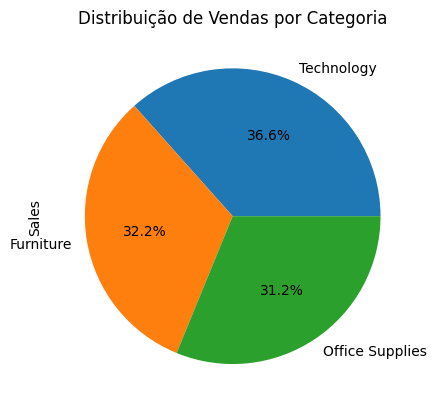

In [22]:
focus_area = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
focus_area.plot(kind='pie', autopct='%1.1f%%', title='Distribuição de Vendas por Categoria')

<Axes: title={'center': 'Distribuição de Vendas por Categoria'}, ylabel='Sales'>

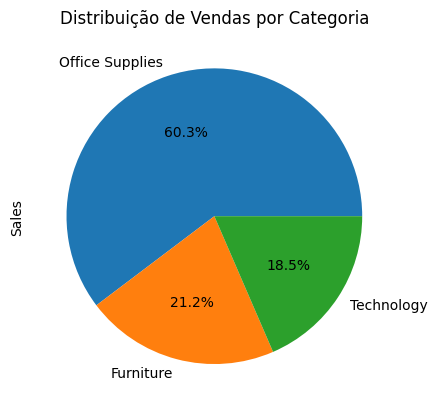

In [23]:
focus_area = df.groupby('Category')['Sales'].count().sort_values(ascending=False)
focus_area.plot(kind='pie', autopct='%1.1f%%', title='Distribuição de Vendas por Categoria')

                 Quantidade de Pedidos  Faturamento Total
Category                                                 
Furniture                        21.20              32.22
Office Supplies                  60.30              31.19
Technology                       18.50              36.59


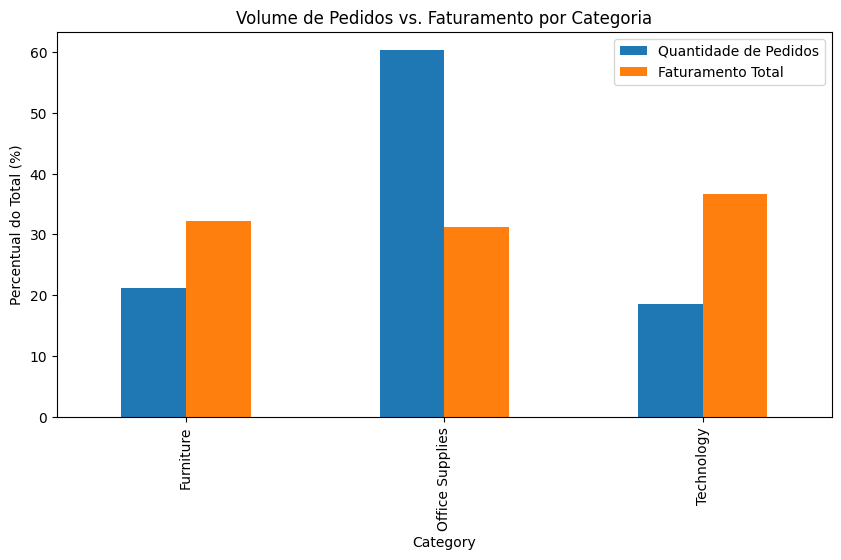

In [24]:
# Criando as duas métricas
vendas_por_cat = df.groupby('Category')['Sales'].agg(['count', 'sum'])

# Renomeando para ficar claro
vendas_por_cat.columns = ['Quantidade de Pedidos', 'Faturamento Total']

# Normalizando para 100% para comparar fatias
vendas_por_cat_pct = vendas_por_cat.div(vendas_por_cat.sum(), axis=1) * 100

print(vendas_por_cat_pct)

# Gráfico de barras comparativo
vendas_por_cat_pct.plot(kind='bar', figsize=(10,5), title='Volume de Pedidos vs. Faturamento por Categoria')
plt.ylabel('Percentual do Total (%)')
plt.show()